# Harris Corner Detection
This section applies Harris Corner Detection to identify important feature points (corners) in medical images.

In [70]:
#Import Libraries
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os
import random

In [71]:
#Load Dataset
image_paths = []

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        if file.endswith(".jpg"):
            image_paths.append(os.path.join(root, file))

print("Total images:", len(image_paths))

Total images: 20030


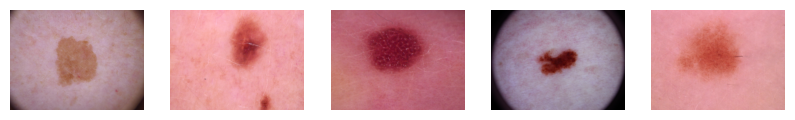

In [72]:
#Sample Images
sample_paths = random.sample(image_paths, 5)

plt.figure(figsize=(10,5))

for i, path in enumerate(sample_paths):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    plt.subplot(1,5,i+1)
    plt.imshow(img)
    plt.axis('off')

plt.show()

## Single Image Harris Detection

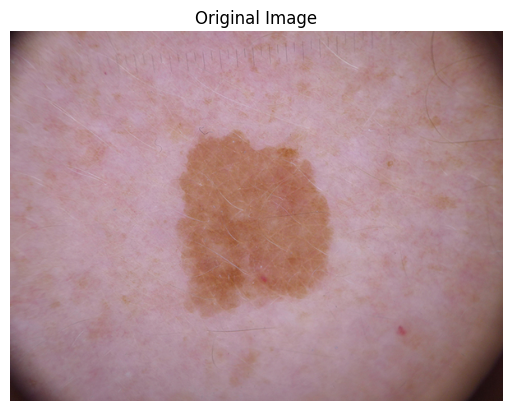

In [73]:
# Read image
img = cv2.imread(sample_paths[0])
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis('off')
plt.show()

In [74]:
# Convert to grayscale
gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
gray = np.float32(gray)

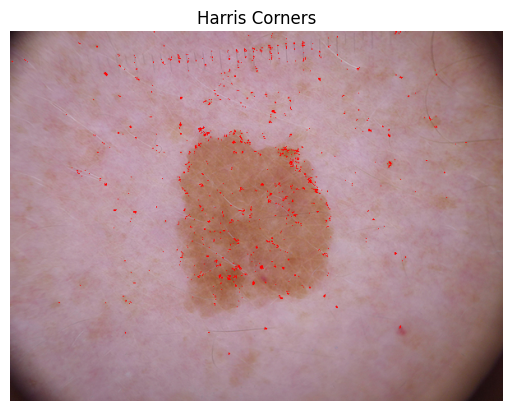

In [75]:
# Apply Harris
dst = cv2.cornerHarris(gray, 2, 3, 0.04)

# Highlight corners
img_harris = img_rgb.copy()
img_harris[dst > 0.01 * dst.max()] = [255, 0, 0]

plt.imshow(img_harris)
plt.title("Harris Corners")
plt.axis('off')
plt.show()

## Observations

- Harris detects corner points in the image.
- Corners represent areas with strong intensity changes.
- These points are useful for feature extraction.

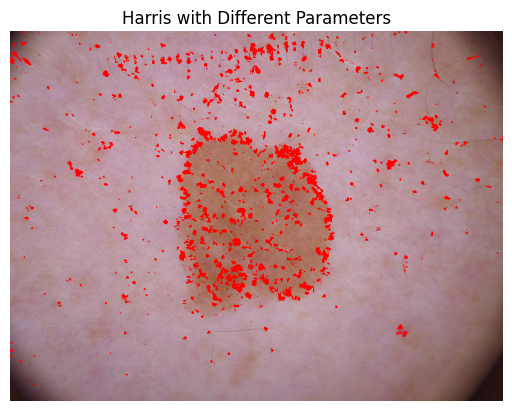

In [76]:
## Parameter Tuning
dst2 = cv2.cornerHarris(gray, 4, 5, 0.04)

img_harris2 = img_rgb.copy()
img_harris2[dst2 > 0.01 * dst2.max()] = [255, 0, 0]

plt.imshow(img_harris2)
plt.title("Harris with Different Parameters")
plt.axis('off')
plt.show()

## Applying Harris on Multiple Images

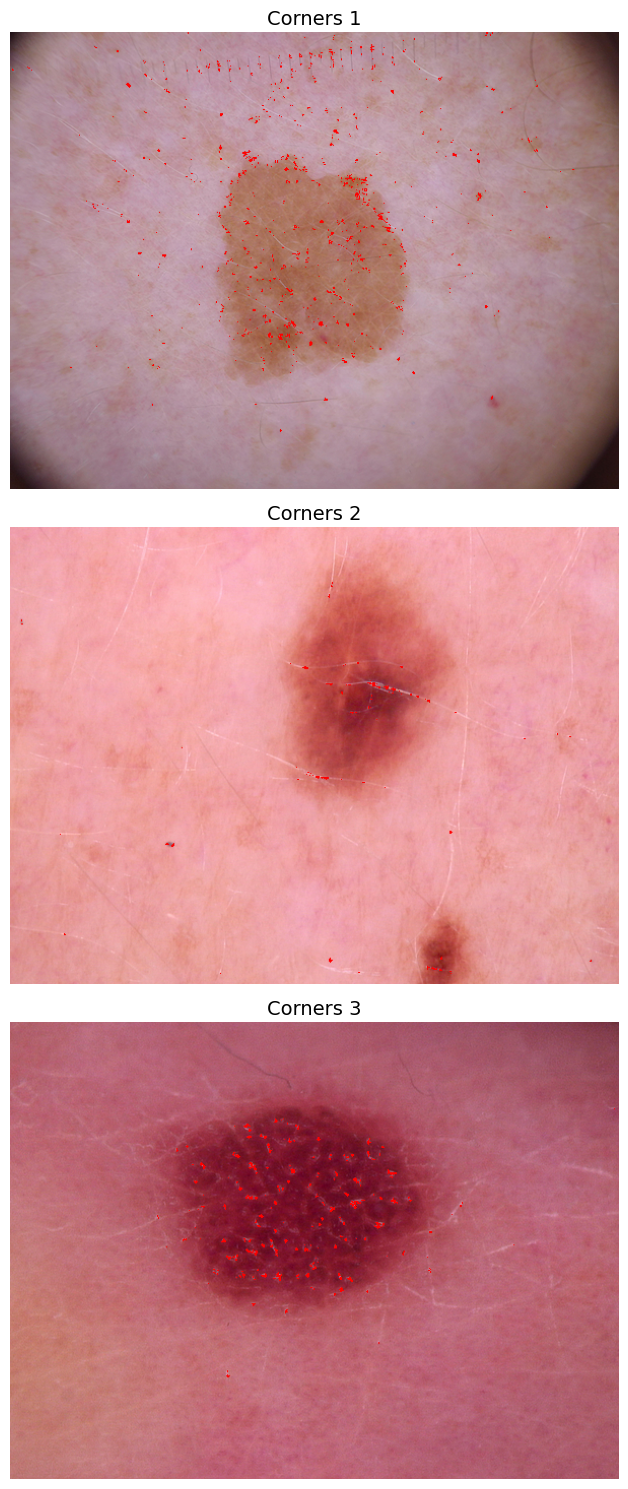

In [77]:
plt.figure(figsize=(8,15))

for i, path in enumerate(sample_paths[:3]):
    
    img = cv2.imread(path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    gray = np.float32(gray)
    
    dst = cv2.cornerHarris(gray, 2, 3, 0.04)
    
    img_copy = img_rgb.copy()
    img_copy[dst > 0.01 * dst.max()] = [255, 0, 0]
    
    plt.subplot(3,1,i+1)  
    plt.imshow(img_copy)
    plt.title(f"Corners {i+1}", fontsize=14)
    plt.axis('off')

plt.tight_layout()
plt.show()

## Observations

- Harris Corner Detection highlights regions with strong intensity changes.
- In medical images, corners often appear around lesion boundaries and textured areas.
- Increasing parameters results in detecting more corner points.
- Higher sensitivity may introduce noise.
- There is a trade-off between detecting important features and avoiding false positives.